In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
from src.data_loader import (
    load_application_train,
    load_bureau,
    load_previous_application,
)

train = load_application_train()
bureau = load_bureau()
previous = load_previous_application()



In [7]:
df = train.copy()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import lightgbm as lgb

# Отделяем целевую переменную
X = df.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')
y = df['TARGET']

# Разбиваем на train/valid
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Valid size:", X_valid.shape)
print("Доля дефолта в train:", y_train.mean().round(4))
print("Доля дефолта в valid:", y_valid.mean().round(4))

# Обучаем LightGBM
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'   # учитываем дисбаланс
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)]
)

# Предсказания и метрики
y_pred_proba = model.predict_proba(X_valid)[:, 1]
y_pred = model.predict(X_valid)

print("\nROC-AUC на валидации:", roc_auc_score(y_valid, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_valid, y_pred, digits=3))

Train size: (246008, 129)
Valid size: (61503, 129)
Доля дефолта в train: 0.0807
Доля дефолта в valid: 0.0807


/Users/ivan/Desktop/credit-default-risk/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035192 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13283
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 125
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[281]	valid_0's auc: 0.770638	valid_0's binary_logloss: 0.548204

ROC-AUC на валидации: 0.7706380547663991

Classification Report:
              precision    recall  f1-score   support

           0      0.962     0.722     0.825     56538
           1      0.176     0.679     0.280      4965

    accuracy                          0.718    

Топ-25 самых важных признаков:


,feature,importance
127,CREDIT_ANNUITY_RATIO,812
39,EXT_SOURCE_1,477
41,EXT_SOURCE_3,457
40,EXT_SOURCE_2,439
128,GOODS_CREDIT_RATIO,326
15,DAYS_BIRTH,244
7,AMT_ANNUITY,231
18,DAYS_ID_PUBLISH,221
93,DAYS_LAST_PHONE_CHANGE,212
121,AGE_YEARS,209


/var/folders/m9/qrthykks5d189t1s8cn6y4y40000gn/T/ipykernel_62418/2328930146.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(20), x='importance', y='feature', palette='viridis')


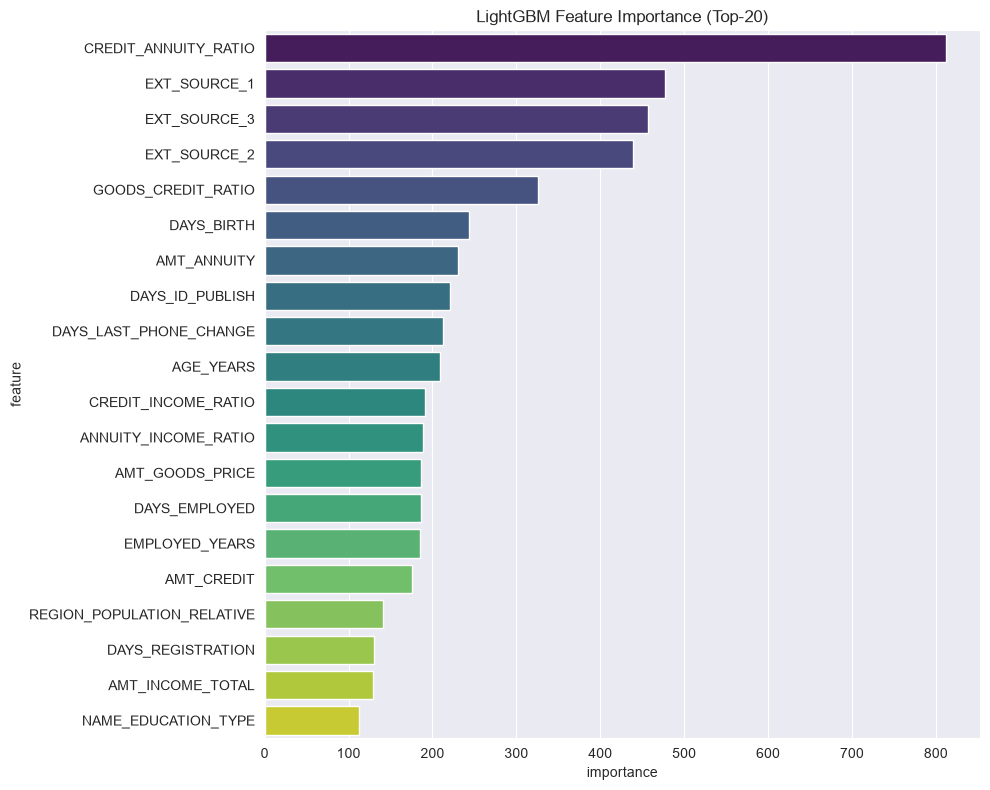

In [10]:
# Feature Importance
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Топ-25 самых важных признаков:")
display(importance.head(25))

# Визуализация топ-20
plt.figure(figsize=(10, 8))
sns.barplot(data=importance.head(20), x='importance', y='feature', palette='viridis')
plt.title('LightGBM Feature Importance (Top-20)')
plt.tight_layout()
plt.show()


In [11]:
import joblib

joblib.dump(model, "/Users/ivan/Desktop/credit-default-risk/models/lightgbm.pkl")

['/Users/ivan/Desktop/credit-default-risk/models/lightgbm.pkl']

In [33]:
print("Bureau shape:", bureau.shape)
print("Уникальных клиентов в bureau:", bureau['SK_ID_CURR'].nunique())

# Агрегируем
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'DAYS_CREDIT': ['count', 'mean', 'max', 'min'],
    'CREDIT_DAY_OVERDUE': ['mean', 'max'],
    'DAYS_CREDIT_ENDDATE': ['mean', 'max'],
    'AMT_CREDIT_MAX_OVERDUE': ['mean', 'max'],
    'CNT_CREDIT_PROLONG': ['mean', 'sum'],
    'AMT_CREDIT_SUM': ['mean', 'sum', 'max'],
    'AMT_CREDIT_SUM_DEBT': ['mean', 'sum'],
    'AMT_CREDIT_SUM_LIMIT': ['mean', 'sum'],
    'AMT_CREDIT_SUM_OVERDUE': ['mean', 'sum'],
    'DAYS_CREDIT_UPDATE': ['mean', 'max'],
    'AMT_ANNUITY': ['mean', 'sum']
})

# Упрощаем названия столбцов
bureau_agg.columns = ['_'.join(col).strip() for col in bureau_agg.columns.values]
bureau_agg = bureau_agg.reset_index()

# Добавляем количество активных и закрытых кредитов
bureau_active = bureau[bureau['CREDIT_ACTIVE'] == 'Active'].groupby('SK_ID_CURR').size().reset_index(
    name='BUREAU_ACTIVE_COUNT')
bureau_closed = bureau[bureau['CREDIT_ACTIVE'] == 'Closed'].groupby('SK_ID_CURR').size().reset_index(
    name='BUREAU_CLOSED_COUNT')

bureau_agg = bureau_agg.merge(bureau_active, on='SK_ID_CURR', how='left')
bureau_agg = bureau_agg.merge(bureau_closed, on='SK_ID_CURR', how='left')

print("Bureau агрегаты shape:", bureau_agg.shape)
display(bureau_agg.head())

Bureau shape: (1716428, 17)
Уникальных клиентов в bureau: 305811
Bureau агрегаты shape: (305811, 28)


,SK_ID_CURR,DAYS_CREDIT_count,DAYS_CREDIT_mean,DAYS_CREDIT_max,DAYS_CREDIT_min,CREDIT_DAY_OVERDUE_mean,CREDIT_DAY_OVERDUE_max,DAYS_CREDIT_ENDDATE_mean,DAYS_CREDIT_ENDDATE_max,AMT_CREDIT_MAX_OVERDUE_mean,...,AMT_CREDIT_SUM_LIMIT_mean,AMT_CREDIT_SUM_LIMIT_sum,AMT_CREDIT_SUM_OVERDUE_mean,AMT_CREDIT_SUM_OVERDUE_sum,DAYS_CREDIT_UPDATE_mean,DAYS_CREDIT_UPDATE_max,AMT_ANNUITY_mean,AMT_ANNUITY_sum,BUREAU_ACTIVE_COUNT,BUREAU_CLOSED_COUNT
0,100001,7,-735.000000,-49,-1572,0.0,0,82.428571,1778.0,NaN,...,0.00000,0.000,0.0,0.0,-93.142857,-6,3545.357143,24817.5,3.0,4.0
1,100002,8,-874.000000,-103,-1437,0.0,0,-349.000000,780.0,1681.029,...,7997.14125,31988.565,0.0,0.0,-499.875000,-7,0.000000,0.0,2.0,6.0
2,100003,4,-1400.750000,-606,-2586,0.0,0,-544.500000,1216.0,0.000,...,202500.00000,810000.000,0.0,0.0,-816.000000,-43,NaN,0.0,1.0,3.0
3,100004,2,-867.000000,-408,-1326,0.0,0,-488.500000,-382.0,0.000,...,0.00000,0.000,0.0,0.0,-532.000000,-382,NaN,0.0,NaN,2.0
4,100005,3,-190.666667,-62,-373,0.0,0,439.333333,1324.0,0.000,...,0.00000,0.000,0.0,0.0,-54.333333,-11,1420.500000,4261.5,2.0,1.0


In [34]:
print("Previous application shape:", prev.shape)
print("Уникальных клиентов:", prev['SK_ID_CURR'].nunique())

# Основные агрегаты
prev_agg = prev.groupby('SK_ID_CURR').agg({
    'AMT_ANNUITY': ['mean', 'sum', 'max'],
    'AMT_APPLICATION': ['mean', 'sum', 'max'],
    'AMT_CREDIT': ['mean', 'sum', 'max'],
    'AMT_DOWN_PAYMENT': ['mean', 'sum', 'max'],
    'AMT_GOODS_PRICE': ['mean', 'sum', 'max'],
    'DAYS_DECISION': ['mean', 'max', 'min'],
    'CNT_PAYMENT': ['mean', 'sum'],
    'DAYS_FIRST_DRAWING': ['mean', 'min'],
    'DAYS_FIRST_DUE': ['mean', 'min'],
    'DAYS_LAST_DUE_1ST_VERSION': ['mean'],
    'DAYS_LAST_DUE': ['mean'],
    'DAYS_TERMINATION': ['mean']
})

prev_agg.columns = ['_'.join(col).strip() for col in prev_agg.columns.values]
prev_agg = prev_agg.reset_index()

# Количество одобренных / отклонённых заявок
prev_approved = prev[prev['NAME_CONTRACT_STATUS'] == 'Approved'].groupby('SK_ID_CURR').size().reset_index(
    name='PREV_APPROVED_COUNT')
prev_refused = prev[prev['NAME_CONTRACT_STATUS'] == 'Refused'].groupby('SK_ID_CURR').size().reset_index(
    name='PREV_REFUSED_COUNT')
prev_canceled = prev[prev['NAME_CONTRACT_STATUS'] == 'Canceled'].groupby('SK_ID_CURR').size().reset_index(
    name='PREV_CANCELED_COUNT')

prev_agg = prev_agg.merge(prev_approved, on='SK_ID_CURR', how='left')
prev_agg = prev_agg.merge(prev_refused, on='SK_ID_CURR', how='left')
prev_agg = prev_agg.merge(prev_canceled, on='SK_ID_CURR', how='left')

print("Previous агрегаты shape:", prev_agg.shape)
display(prev_agg.head())

Previous application shape: (1670214, 37)
Уникальных клиентов: 338857
Previous агрегаты shape: (338857, 31)


,SK_ID_CURR,AMT_ANNUITY_mean,AMT_ANNUITY_sum,AMT_ANNUITY_max,AMT_APPLICATION_mean,AMT_APPLICATION_sum,AMT_APPLICATION_max,AMT_CREDIT_mean,AMT_CREDIT_sum,AMT_CREDIT_max,...,DAYS_FIRST_DRAWING_mean,DAYS_FIRST_DRAWING_min,DAYS_FIRST_DUE_mean,DAYS_FIRST_DUE_min,DAYS_LAST_DUE_1ST_VERSION_mean,DAYS_LAST_DUE_mean,DAYS_TERMINATION_mean,PREV_APPROVED_COUNT,PREV_REFUSED_COUNT,PREV_CANCELED_COUNT
0,100001,3951.000,3951.000,3951.000,24835.50,24835.5,24835.5,23787.00,23787.0,23787.0,...,365243.0,365243.0,-1709.000000,-1709.0,-1499.000000,-1619.000000,-1612.000000,1.0,NaN,NaN
1,100002,9251.775,9251.775,9251.775,179055.00,179055.0,179055.0,179055.00,179055.0,179055.0,...,365243.0,365243.0,-565.000000,-565.0,125.000000,-25.000000,-17.000000,1.0,NaN,NaN
2,100003,56553.990,169661.970,98356.995,435436.50,1306309.5,900000.0,484191.00,1452573.0,1035882.0,...,365243.0,365243.0,-1274.333333,-2310.0,-1004.333333,-1054.333333,-1047.333333,3.0,NaN,NaN
3,100004,5357.250,5357.250,5357.250,24282.00,24282.0,24282.0,20106.00,20106.0,20106.0,...,365243.0,365243.0,-784.000000,-784.0,-694.000000,-724.000000,-714.000000,1.0,NaN,NaN
4,100005,4813.200,4813.200,4813.200,22308.75,44617.5,44617.5,20076.75,40153.5,40153.5,...,365243.0,365243.0,-706.000000,-706.0,-376.000000,-466.000000,-460.000000,1.0,NaN,1.0


In [14]:
# Сохраняем текущий размер для сравнения
print("Размер df до merge:", df.shape)

# Мержим bureau и previous
df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
df = df.merge(prev_agg, on='SK_ID_CURR', how='left')

print("Размер df после merge:", df.shape)

# Заполняем пропуски в новых признаках (клиенты без истории)
new_features = [c for c in df.columns if c not in X.columns and c not in ['TARGET', 'SK_ID_CURR']]
print(f"\nДобавлено новых признаков: {len(new_features)}")

# Заполняем медианой числовые (все новые признаки числовые)
for col in new_features:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Пропуски после заполнения:", df.isnull().sum().sum())

Размер df до merge: (307511, 131)
Размер df после merge: (307511, 188)

Добавлено новых признаков: 57
Пропуски после заполнения: 0


In [15]:
# Готовим данные заново
X = df.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')
y = df['TARGET']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model2 = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

model2.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

y_pred_proba2 = model2.predict_proba(X_valid)[:, 1]
auc2 = roc_auc_score(y_valid, y_pred_proba2)

print("ROC-AUC до добавления bureau/previous: 0.7299")
print("ROC-AUC после добавления bureau/previous:", round(auc2, 4))
print("Прирост:", round(auc2 - 0.7299, 4))

/Users/ivan/Desktop/credit-default-risk/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039419 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25806
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 182
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
ROC-AUC до добавления bureau/previous: 0.7299
ROC-AUC после добавления bureau/previous: 0.7808
Прирост: 0.0509


In [16]:
pip install shap


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/Users/ivan/Desktop/credit-default-risk/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


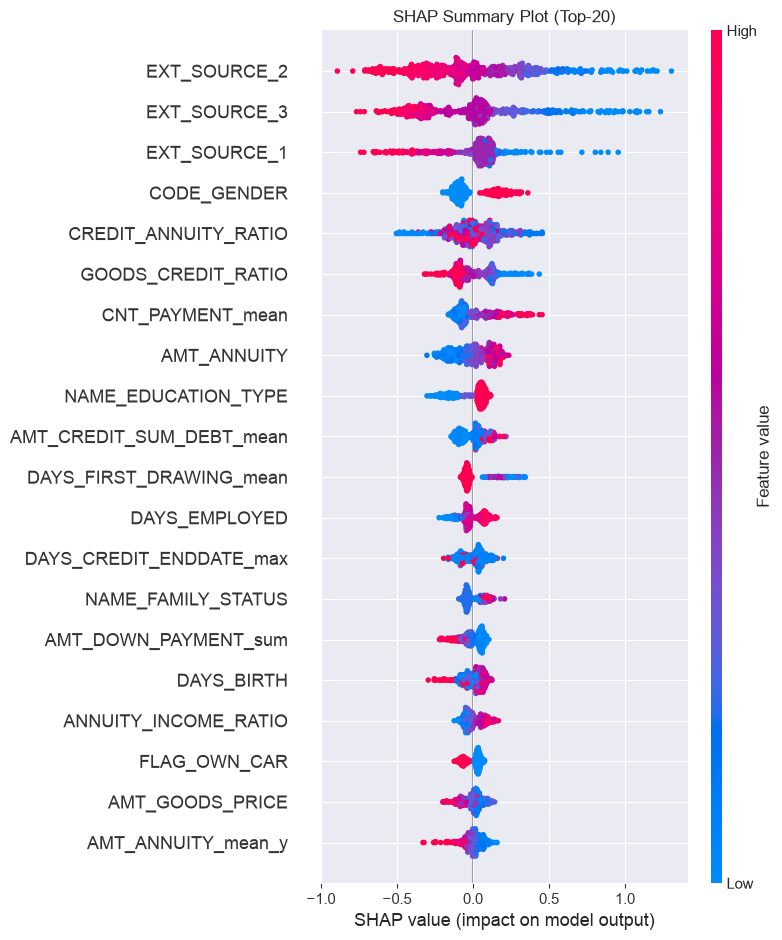

In [17]:
import shap

# Берём небольшую выборку для скорости (SHAP на всех данных считается долго)
X_sample = X_valid.sample(500, random_state=42)

# Создаём explainer
explainer = shap.TreeExplainer(model2)
shap_values = explainer.shap_values(X_sample)

# Summary plot (самый информативный)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title("SHAP Summary Plot (Top-20)")
plt.tight_layout()
plt.show()

Brier Score до калибровки: 0.1721
Brier Score после калибровки: 0.066
ROC-AUC после калибровки: 0.7819


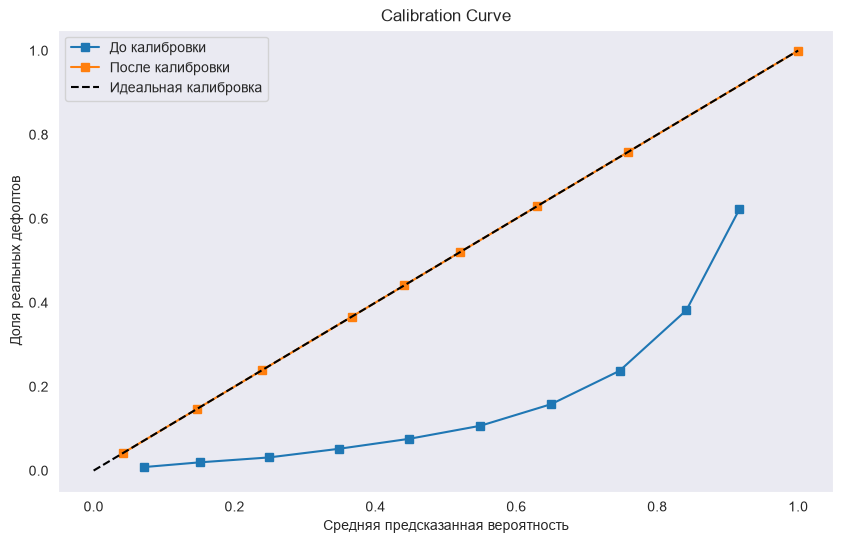

In [21]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.frozen import FrozenEstimator   # для новых версий sklearn

# ===== Вариант 1 (рекомендуется для новых версий scikit-learn) =====
try:
    calibrated_model = CalibratedClassifierCV(
        FrozenEstimator(model2),
        method='isotonic'
    )
    calibrated_model.fit(X_valid, y_valid)

except Exception:
    # ===== Вариант 2 (если FrozenEstimator не работает) =====
    calibrated_model = CalibratedClassifierCV(
        estimator=model2,
        method='isotonic',
        cv=3
    )
    calibrated_model.fit(X_train, y_train)

# Предсказания до и после калибровки
proba_raw = model2.predict_proba(X_valid)[:, 1]
proba_cal = calibrated_model.predict_proba(X_valid)[:, 1]

print("Brier Score до калибровки:", round(brier_score_loss(y_valid, proba_raw), 4))
print("Brier Score после калибровки:", round(brier_score_loss(y_valid, proba_cal), 4))
print("ROC-AUC после калибровки:", round(roc_auc_score(y_valid, proba_cal), 4))

# Calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(y_valid, proba_raw, n_bins=10)
fraction_of_positives_cal, mean_predicted_value_cal = calibration_curve(y_valid, proba_cal, n_bins=10)

plt.figure(figsize=(10, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="До калибровки")
plt.plot(mean_predicted_value_cal, fraction_of_positives_cal, "s-", label="После калибровки")
plt.plot([0, 1], [0, 1], "k--", label="Идеальная калибровка")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Доля реальных дефолтов")
plt.title("Calibration Curve")
plt.legend()
plt.grid()
plt.show()

In [22]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 908.6 kB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
import optuna
from optuna.samplers import TPESampler

def objective(trial):
    params = {
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 80),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'class_weight': 'balanced',
        'verbose': -1
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )

    preds = model.predict_proba(X_valid)[:, 1]
    return roc_auc_score(y_valid, preds)

# Запускаем оптимизацию (30 trials — обычно достаточно для хорошего прироста)
sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Лучший AUC:", round(study.best_value, 4))
print("Лучшие параметры:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-08-07 06:30:44,685] A new study created in memory with name: no-name-98c0c967-8b7b-4c4a-93f0-02c80ef71e06


  0%|          | 0/30 [00:00<?, ?it/s]

/Users/ivan/Desktop/credit-default-risk/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[I 2026-08-07 06:31:17,943] Trial 0 finished with value: 0.7822957953543496 and parameters: {'learning_rate': 0.023688639503640783, 'num_leaves': 77, 'max_depth': 9, 'min_child_samples': 68, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.915443189153755}. Best is trial 0 with value: 0.7822957953543496.


/Users/ivan/Desktop/credit-default-risk/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


...

[I 2026-08-07 06:58:20,955] Trial 27 finished with value: 0.7817645126127327 and parameters: {'learning_rate': 0.036264872919478046, 'num_leaves': 41, 'max_depth': 8, 'min_child_samples': 60, 'subsample': 0.6829706903115174, 'colsample_bytree': 0.8186809408987953, 'reg_alpha': 0.32829302290467366, 'reg_lambda': 0.015197859542042384}. Best is trial 12 with value: 0.7828296394475502.


/Users/ivan/Desktop/credit-default-risk/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[I 2026-08-07 06:58:40,186] Trial 28 finished with value: 0.7817183227870841 and parameters: {'learning_rate': 0.026839506263898555, 'num_leaves': 37, 'max_depth': 6, 'min_child_samples': 72, 'subsample': 0.7685501732158674, 'colsample_bytree': 0.7409990977324303, 'reg_alpha': 0.10408357133899686, 'reg_lambda': 0.0012627412886924531}. Best is trial 12 with value: 0.7828296394475502.


/Users/ivan/Desktop/credit-default-risk/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[I 2026-08-07 06:59:02,446] Trial 29 finished with value: 0.7814177113080324 and parameters: {'learning_rate': 0.02321978510000334, 'num_leaves': 25, 'max_depth': 7, 'min_child_samples': 64, 'subsample': 0.6477639824328913, 'colsample_bytree': 0.8912101550266426, 'reg_alpha': 0.04048692591868054, 'reg_lambda': 0.08964084133488796}. Best is trial 12 with value: 0.7828296394475502.
Лучший AUC: 0.7828
Лучшие параметры:
  learning_rate: 0.01860317157966074
  num_leaves: 80
  max_depth: 9
  min_child_samples: 64
  subsample: 0.6840099903683542
  colsample_bytree: 0.6037244622276555
  reg_alpha: 0.11837495089796485
  reg_lambda: 0.7274072036882728


In [24]:
best_params = {
    'n_estimators': 1000,
    'learning_rate': 0.052328650307087825,
    'num_leaves': 27,
    'max_depth': 9,
    'min_child_samples': 55,
    'subsample': 0.8939112117287688,
    'colsample_bytree': 0.6978843182022244,
    'reg_alpha': 0.6206097649580387,
    'reg_lambda': 0.2810618649300135,
    'random_state': 42,
    'n_jobs': -1,
    'class_weight': 'balanced',
    'verbose': -1
}

final_model = lgb.LGBMClassifier(**best_params)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)]
)

final_proba = final_model.predict_proba(X_valid)[:, 1]
final_auc = roc_auc_score(y_valid, final_proba)

print("Финальный ROC-AUC:", round(final_auc, 4))

/Users/ivan/Desktop/credit-default-risk/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[499]	valid_0's auc: 0.781913	valid_0's binary_logloss: 0.517276
Финальный ROC-AUC: 0.7819


In [27]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

# Калибровка
calibrated_final = CalibratedClassifierCV(final_model, method='isotonic', cv=3)
calibrated_final.fit(X_train, y_train)

proba_final_raw = final_model.predict_proba(X_valid)[:, 1]
proba_final_cal = calibrated_final.predict_proba(X_valid)[:, 1]

print("Brier Score до калибровки:", round(brier_score_loss(y_valid, proba_final_raw), 4))
print("Brier Score после калибровки:", round(brier_score_loss(y_valid, proba_final_cal), 4))
print("ROC-AUC после калибровки:", round(roc_auc_score(y_valid, proba_final_cal), 4))

Brier Score до калибровки: 0.1723
Brier Score после калибровки: 0.0662
ROC-AUC после калибровки: 0.7815
